In [1]:
# Create Linear Data
import torch
import random
import numpy
from itertools import product

S = [-1.0, -0.5, 0.0, 0.5, 1.0]

linear_data = torch.zeros([25, 2])
linear_labels = torch.zeros([25])

count = 0
for x1, x2 in product(S, repeat=2):
    linear_data[count][0] = x1
    linear_data[count][1] = x2
    linear_labels[count] = 1 if x2>x1 else 0
    count += 1

# Create XOR data
xor_data = torch.tensor([[1.0, 1.0], [1.0, -1.0], [-1.0, -1.0], [-1.0, 1.0]])
xor_labels = torch.tensor([0, 1, 0, 1])

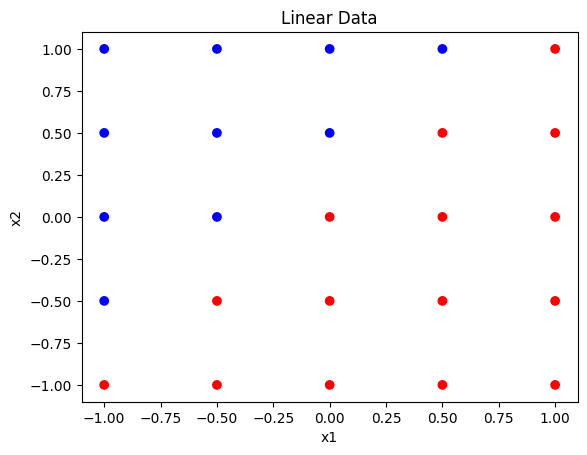

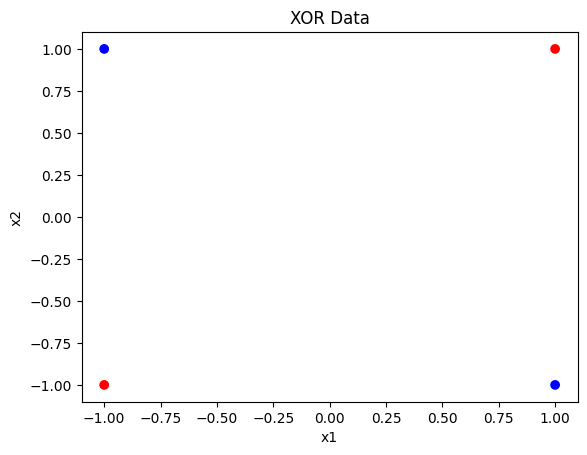

In [ ]:
# Create the scatterplots
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

colors = ["red", "blue"]
cmap = LinearSegmentedColormap.from_list('my_cmap', colors, N=100)

# Plot linear data
plt.scatter(linear_data[:, 0], linear_data[:, 1], cmap=cmap, c=linear_labels)
plt.title("Linear Data")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

# Plot the XOR Data
plt.scatter(xor_data[:, 0], xor_data[:, 1], cmap=cmap, c=xor_labels)
plt.title("XOR Data")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

In [ ]:
# Perceptron Class
class Perceptron:
    def __init__(self, lr, input_size, output_size = 1):
        self.input_size = input_size
        self.output_size = output_size
        self.weights = torch.randn(input_size, output_size)
        self.bias = torch.zeros(output_size)
        self.lr = lr

    def step_function(self, x):
        return torch.where(x > 0, 1, 0)

    def forward(self, x):
        output = torch.matmul(x, self.weights) + self.bias
        output = self.step_function(output)
        return output

    def backward(self, X, Y):
        avg_loss = 0
        for x_i, y_i in zip(X, Y):
            y_pred = self.forward(x_i)
            loss = y_i - y_pred
            update = self.lr * loss
            self.weights += update * x_i.unsqueeze(1)
            self.bias += update
            avg_loss += abs(loss.item())
        return avg_loss / len(X)

    def fit(self, X, Y, epochs):
        losses = []
        angles = []
        accuracies = []
        for epoch in range(epochs):
            avg_loss = self.backward(X, Y)
            predictions = self.forward(X)
            accuracy = (predictions.squeeze() == Y).float().mean() * 100

            angle = numpy.arctan(self.weights[1][0] / self.weights[0][0]) + numpy.pi / 2
            angle = numpy.degrees(angle)

            if epoch % 10 == 0:
                print(f"Epoch: {epoch}")
                print(f"Average Loss: {avg_loss}")
                print(f"Angle: {angle}")
                print(f"Accuracy: {accuracy:.2f}")
                print("="*10)
            losses.append(avg_loss)
            angles.append(float(angle))
            accuracies.append(float(accuracy))
        return angles, accuracies, self.weights, self.bias

In [ ]:
input_size = 2
output_size = 1

# Linear Data
epochs = 100
learning_rate = 0.001

model = Perceptron(learning_rate, input_size, output_size)
lin_angles, lin_accuracies, lin_weights, lin_bias = model.fit(linear_data, linear_labels, epochs)

Epoch: 0
Average Loss: 0.92
Angle: 59.96644973754883
Accuracy: 12.00
Epoch: 10
Average Loss: 0.84
Angle: 63.10750198364258
Accuracy: 16.00
Epoch: 20
Average Loss: 0.8
Angle: 72.15441131591797
Accuracy: 28.00
Epoch: 30
Average Loss: 0.0
Angle: 48.85357666015625
Accuracy: 100.00
Epoch: 40
Average Loss: 0.0
Angle: 48.85357666015625
Accuracy: 100.00
Epoch: 50
Average Loss: 0.0
Angle: 48.85357666015625
Accuracy: 100.00
Epoch: 60
Average Loss: 0.0
Angle: 48.85357666015625
Accuracy: 100.00
Epoch: 70
Average Loss: 0.0
Angle: 48.85357666015625
Accuracy: 100.00
Epoch: 80
Average Loss: 0.0
Angle: 48.85357666015625
Accuracy: 100.00
Epoch: 90
Average Loss: 0.0
Angle: 48.85357666015625
Accuracy: 100.00


/tmp/ipython-input-1972058851.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  angle = numpy.arctan(self.weights[1][0] / self.weights[0][0]) + numpy.pi / 2
/tmp/ipython-input-1972058851.py:39: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  angle = numpy.degrees(angle)


In [ ]:
# XOR Data
epochs = 100
learning_rate = 0.1

model = Perceptron(learning_rate, input_size, output_size)
xor_angles, xor_accuracies, xor_weights, xor_bias = model.fit(xor_data, xor_labels, epochs)

tensor([0.])
Epoch: 0
Average Loss: 0.5
Angle: 48.0592041015625
Accuracy: 50.00
tensor([0.])
tensor([0.])
tensor([0.])
tensor([0.])
tensor([0.])
tensor([0.])
tensor([0.])
tensor([0.])
tensor([0.])
tensor([0.])
Epoch: 10
Average Loss: 0.5
Angle: 58.64498519897461
Accuracy: 50.00
tensor([0.])
tensor([0.])
tensor([0.])
tensor([0.])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
Epoch: 20
Average Loss: 1.0
Angle: 149.4779510498047
Accuracy: 75.00
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
Epoch: 30
Average Loss: 1.0
Angle: 149.4779510498047
Accuracy: 75.00
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
tensor([0.1000])
Epoch: 40
Average Loss: 1.0
Angle: 149.4779510498047
Accuracy: 75.00
tensor([0.1000])
ten

/tmp/ipython-input-3975417480.py:39: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  angle = numpy.arctan(self.weights[1][0] / self.weights[0][0]) + numpy.pi / 2
/tmp/ipython-input-3975417480.py:40: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  angle = numpy.degrees(angle)


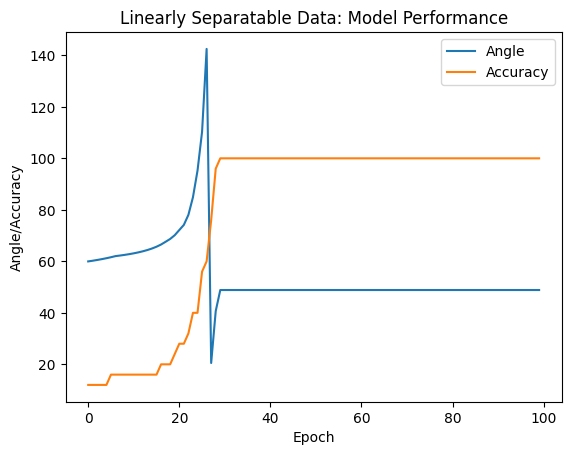

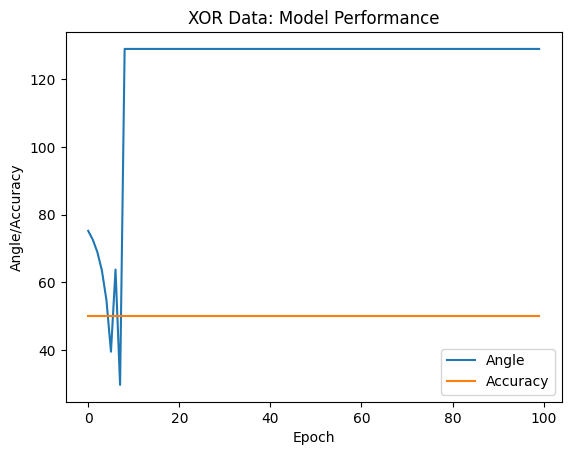

In [ ]:
import matplotlib.pyplot as plt
# Linear Data
epochs = [i for i in range(100)]
plt.plot(epochs, lin_angles)
plt.plot(epochs, lin_accuracies)
plt.title("Linearly Separatable Data: Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Angle/Accuracy")
plt.legend(["Angle", "Accuracy"])
plt.show()

# XOR Data
plt.plot(epochs, xor_angles)
plt.plot(epochs, xor_accuracies)
plt.title("XOR Data: Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Angle/Accuracy")
plt.legend(["Angle", "Accuracy"])
plt.show()

y=1.1444482803344727x+0.1988368034362793


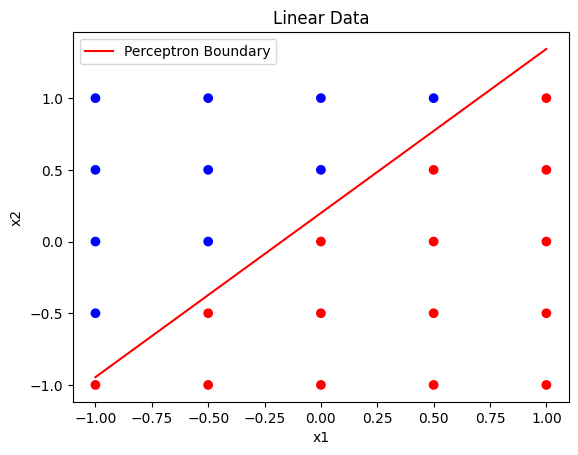

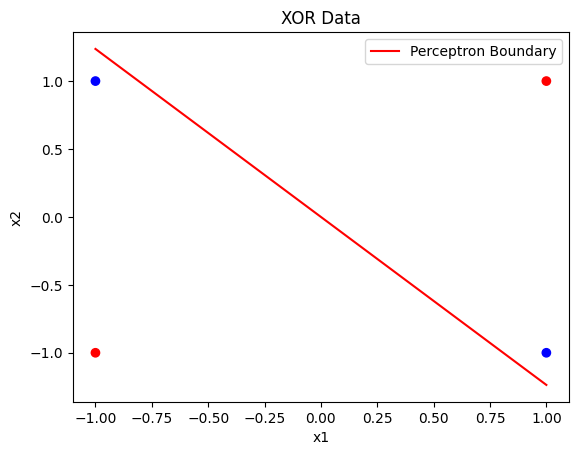

In [ ]:
# Create the scatter plots
# Plot linear data
x1 = lin_weights[0][0]
x2 = lin_weights[1][0]
b = -1 * lin_bias[0] / x2
m = -(x1/x2)
print(f"y={m}x+{b}")
x = torch.linspace(-1, 1, 100)
plt.scatter(linear_data[:, 0], linear_data[:, 1], cmap=cmap, c=linear_labels)
plt.plot(x, m * x + b, color='red', label="Perceptron Boundary")
plt.title("Linear Data")
plt.ylabel("x2")
plt.xlabel("x1")
plt.legend()
plt.show()

# Plot the XOR Data
x1 = xor_weights[0][0]
x2 = xor_weights[1][0]
b = -1 * xor_bias[0] / x2
m = -(x1/x2)
x = torch.linspace(-1, 1, 100)
plt.scatter(xor_data[:, 0], xor_data[:, 1], cmap=cmap, c=xor_labels)
plt.plot(x, m * x + b, color='red', label="Perceptron Boundary")
plt.title("XOR Data")
plt.ylabel("x2")
plt.xlabel("x1")
plt.legend()
plt.show()

In [ ]:
# Create the multi-layer perceptron

# Perceptron Class
class MultiLayerPerceptron:
    def __init__(self, lr, hidden_size, input_size, output_size = 1, random_init = True, custom_init=None):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size = hidden_size
        self.lr = lr

        if custom_init:
            self.w1 = custom_init[0]
            self.w2 = custom_init[1]
        elif random_init:
            self.w1 = torch.randn(input_size, hidden_size)
            self.w2 = torch.randn(hidden_size, output_size)
        else:
            w1_range = 1 / (10 * numpy.sqrt(input_size))
            w2_range = 1 / (10 * numpy.sqrt(hidden_size))
            self.w1 = torch.zeros(input_size, hidden_size)
            self.w2 = torch.zeros(hidden_size, output_size)
            random.seed(42)
            for i in range(len(self.w1[0])):
                for j in range(len(self.w1[1])):
                    self.w1[i][j] = random.uniform(-w1_range, w1_range)
            for i in range(len(self.w2[0])):
                for j in range(len(self.w2[1])):
                    self.w2[i][j] = random.uniform(-w2_range, w2_range)

        self.b1 = torch.zeros(hidden_size)
        self.b2 = torch.zeros(output_size)

    def sigmoid(self, x):
        return 1 / (1 + torch.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, x):
        output1 = torch.matmul(x, self.w1) + self.b1
        self.a1 = self.sigmoid(output1)

        output2 = torch.matmul(self.a1, self.w2) + self.b2
        self.a2 = self.sigmoid(output2)
        return self.a2

    def backward(self, x, y, output):
        error = y.unsqueeze(1) - output
        d_output = error * self.sigmoid_derivative(output)
        error_hidden = torch.matmul(d_output, self.w2.t())
        d_hidden = error_hidden * self.sigmoid_derivative(self.a1)

        self.w2 += self.lr * torch.matmul(self.a1.t(), d_output)
        self.b2 += self.lr * torch.sum(d_output, dim=0)

        self.w1 += self.lr * torch.matmul(x.t(), d_hidden)
        self.b1 += self.lr * torch.sum(d_hidden, dim=0)
        return torch.mean(torch.abs(error))


    def fit(self, X, Y, epochs, print_stats=True):
        losses = []
        accuracies = []
        for epoch in range(epochs):
            output = self.forward(X)

            loss = self.backward(X, Y, output)
            losses.append(loss.item())

            predictions = torch.where(output > 0.5, 1, 0).flatten()
            accuracy = (predictions == Y).float().mean() * 100
            accuracies.append(float(accuracy))

            if print_stats and epoch % 100 == 0:
                print(f"Epoch: {epoch}")
                print(f"Loss: {loss:.4f}")
                print(f"Accuracy: {accuracy:.2f}")
                print("="*10)
        return accuracies

In [ ]:
input_size = 2
hidden_size = 2

# Linear Data
epochs = 1000
learning_rate = 0.1

lin_model = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size)
lin_accuracies = lin_model.fit(linear_data, linear_labels, epochs)

Epoch: 0
Loss: 0.4901
Accuracy: 40.00
Epoch: 100
Loss: 0.1782
Accuracy: 100.00
Epoch: 200
Loss: 0.1073
Accuracy: 100.00
Epoch: 300
Loss: 0.0770
Accuracy: 100.00
Epoch: 400
Loss: 0.0605
Accuracy: 100.00
Epoch: 500
Loss: 0.0502
Accuracy: 100.00
Epoch: 600
Loss: 0.0432
Accuracy: 100.00
Epoch: 700
Loss: 0.0381
Accuracy: 100.00
Epoch: 800
Loss: 0.0343
Accuracy: 100.00
Epoch: 900
Loss: 0.0313
Accuracy: 100.00


In [ ]:
#XOR Data
epochs = 1000
learning_rate = 0.1

xor_model = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size)
xor_accuracies = xor_model.fit(xor_data, xor_labels, epochs)

Epoch: 0
Loss: 0.5005
Accuracy: 50.00
Epoch: 100
Loss: 0.4980
Accuracy: 25.00
Epoch: 200
Loss: 0.4963
Accuracy: 50.00
Epoch: 300
Loss: 0.4934
Accuracy: 50.00
Epoch: 400
Loss: 0.4881
Accuracy: 50.00
Epoch: 500
Loss: 0.4791
Accuracy: 50.00
Epoch: 600
Loss: 0.4652
Accuracy: 50.00
Epoch: 700
Loss: 0.4458
Accuracy: 75.00
Epoch: 800
Loss: 0.4189
Accuracy: 100.00
Epoch: 900
Loss: 0.3814
Accuracy: 100.00


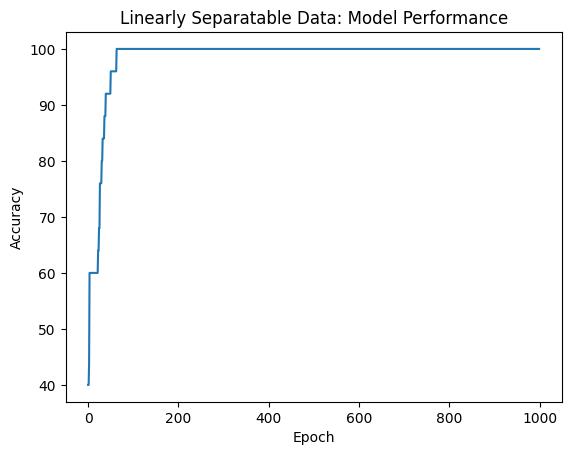

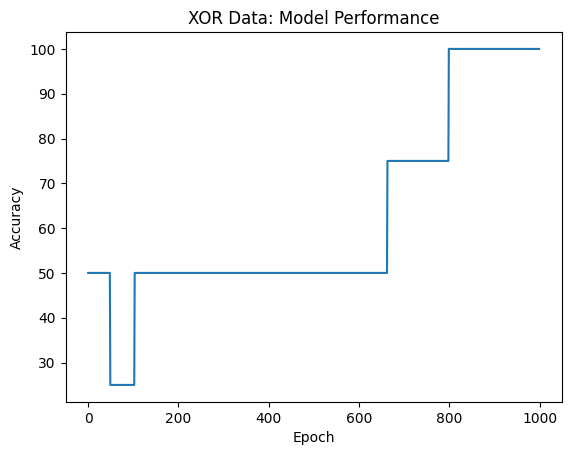

In [ ]:
# plot accuracy vs epoch
import matplotlib.pyplot as plt
# Linear Data
epochs = [i for i in range(1000)]
plt.plot(epochs, lin_accuracies)
plt.title("Linearly Separatable Data: Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# XOR Data
plt.plot(epochs, xor_accuracies)
plt.title("XOR Data: Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# Collect accuracies

def make_test_data(x_range = 2, density = 20):
    step = x_range/(density-1) # account for 0
    test_data = torch.zeros([density*density, 2])
    count = 0
    for i in range(density):
        for j in range(density):
            x1 = (i * step) - int(x_range/2)
            x2 = (j * step) - int(x_range/2)
            test_data[count][0] = x1
            test_data[count][1] = x2
            count += 1
    return test_data

test_data = make_test_data()

# make predictions
linear_labels = lin_model.forward(test_data).flatten()
linear_labels = torch.where(linear_labels > 0.5, 1, 0).flatten()
xor_labels = xor_model.forward(test_data).flatten()
xor_labels = torch.where(xor_labels > 0.5, 1, 0).flatten()

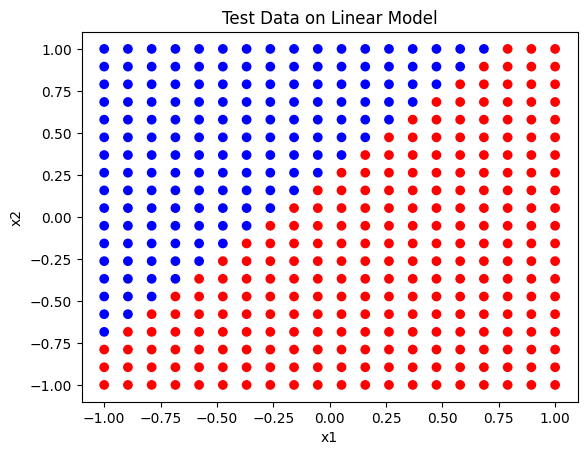

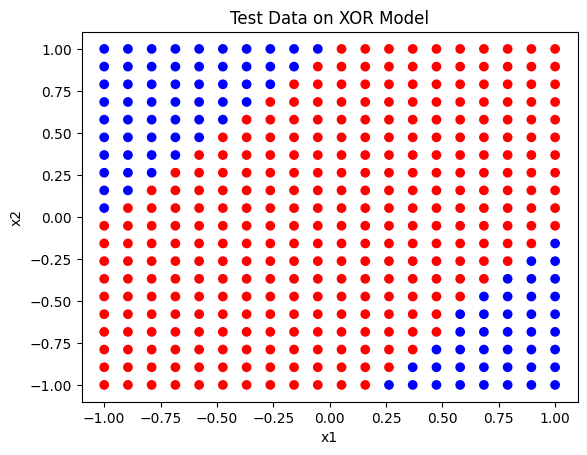

In [ ]:
# plot dummy data
plt.scatter(test_data[:, 0], test_data[:, 1], cmap=cmap, c=linear_labels)
plt.title("Test Data on Linear Model")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

plt.scatter(test_data[:, 0], test_data[:, 1], cmap=cmap, c=xor_labels)
plt.title("Test Data on XOR Model")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

In [ ]:
# Noisy data
noisy_xor_data = torch.zeros(40, 2)
noisy_xor_labels = torch.zeros(40)
count = 0
for i in range(10):
    for j in range(4):
        noisy_xor_data[count] = xor_data[j]
        noisy_xor_labels[count] = xor_labels[j]
        count += 1

noisy_xor_data_sm = noisy_xor_data + 0.25 * torch.randn_like(noisy_xor_data)
noisy_xor_data_md = noisy_xor_data + 0.5 * torch.randn_like(noisy_xor_data)
noisy_xor_data_lg = noisy_xor_data + 0.75 * torch.randn_like(noisy_xor_data)

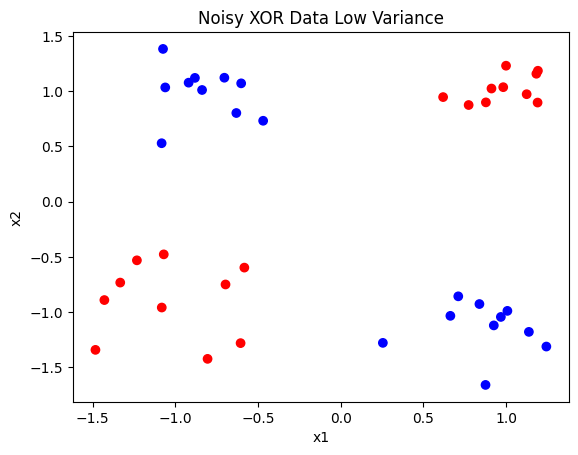

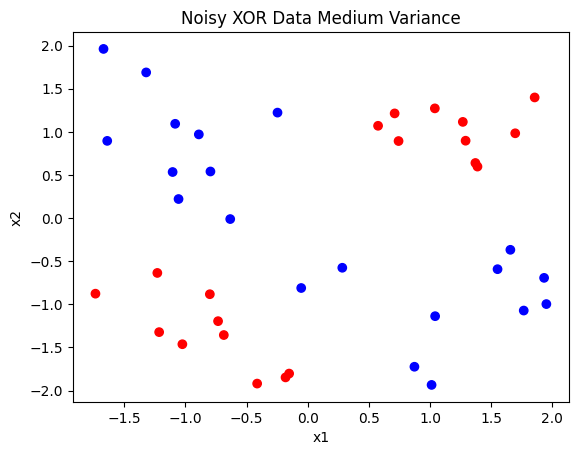

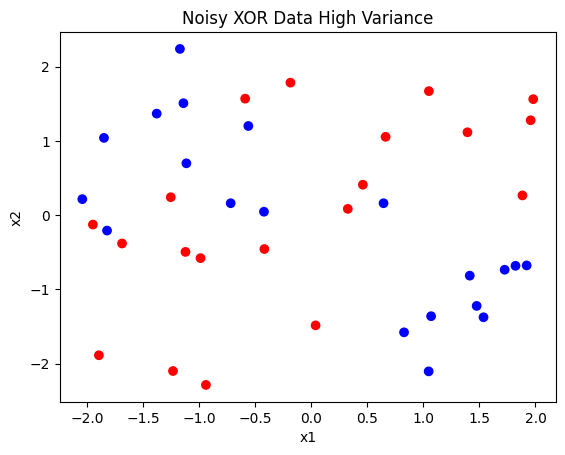

In [ ]:
# create scatterplots
plt.scatter(noisy_xor_data_sm[:, 0], noisy_xor_data_sm[:, 1], cmap=cmap, c=noisy_xor_labels)
plt.title("Noisy XOR Data Low Variance")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

plt.scatter(noisy_xor_data_md[:, 0], noisy_xor_data_md[:, 1], cmap=cmap, c=noisy_xor_labels)
plt.title("Noisy XOR Data Medium Variance")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

plt.scatter(noisy_xor_data_lg[:, 0], noisy_xor_data_lg[:, 1], cmap=cmap, c=noisy_xor_labels)
plt.title("Noisy XOR Data High Variance")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

In [ ]:
# Train 100 models on each dataset
epochs = 1000
learning_rate = 0.1
hidden_size = 2

models = [] #save the models

for i in range(100):
    #small
    xor_model_sm = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size)
    xor_accuracies_sm = xor_model_sm.fit(noisy_xor_data_sm, noisy_xor_labels, epochs, print_stats=False)
    models.append({"model": xor_model_sm, "accuracy": xor_accuracies_sm, "type": "sm"})
    #med
    xor_model_md = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size)
    xor_accuracies_md = xor_model_md.fit(noisy_xor_data_md, noisy_xor_labels, epochs, print_stats=False)
    models.append({"model": xor_model_md, "accuracy": xor_accuracies_md, "type": "md"})
    #large
    xor_model_lg = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size)
    xor_accuracies_lg = xor_model_lg.fit(noisy_xor_data_lg, noisy_xor_labels, epochs, print_stats=False)
    models.append({"model": xor_model_lg, "accuracy": xor_accuracies_lg, "type": "lg"})

0 models trained
30 models trained
60 models trained
90 models trained
120 models trained
150 models trained
180 models trained
210 models trained
240 models trained
270 models trained


In [ ]:
# Find the best performing model
# temporary filler
best_sm = {'accuracy': [-1]}
best_md = {'accuracy': [-1]}
best_lg = {'accuracy': [-1]}
accuracies_sm = []
accuracies_md = []
accuracies_lg = []
for item in models:
    final_accuracy = item['accuracy'][-1]
    if item["type"] == "sm":
        accuracies_sm.append(final_accuracy)
        if final_accuracy > best_sm["accuracy"][-1]:
            best_sm = item

    elif item["type"] == "md":
        accuracies_md.append(final_accuracy)
        if final_accuracy > best_md["accuracy"][-1]:
            best_md = item

    elif item["type"] == "lg":
        accuracies_lg.append(final_accuracy)
        if final_accuracy > best_lg["accuracy"][-1]:
            best_lg = item

print(f"Best small model: {best_sm['accuracy'][-1]}")
print(f"Best medium model: {best_md['accuracy'][-1]}")
print(f"Best large model: {best_lg['accuracy'][-1]}")

Best small model: 100.0
Best medium model: 100.0
Best large model: 85.0


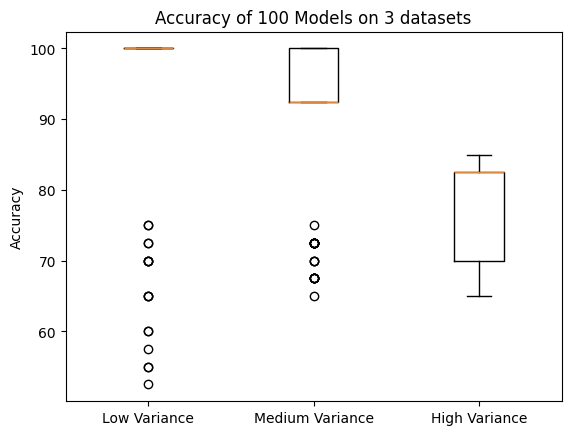

In [ ]:
# plot box and whisker of accuracy
import matplotlib.pyplot as plt
plt.boxplot([accuracies_sm, accuracies_md, accuracies_lg])
plt.xticks([1, 2, 3], ['Low Variance', 'Medium Variance', 'High Variance'])
plt.ylabel('Accuracy')
plt.title('Accuracy of 100 Models on 3 datasets')
plt.show()

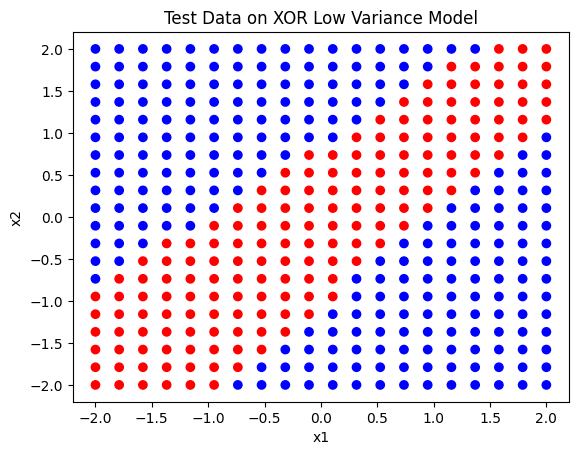

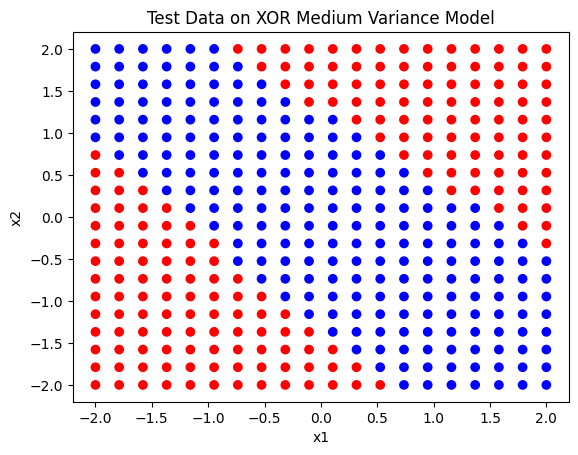

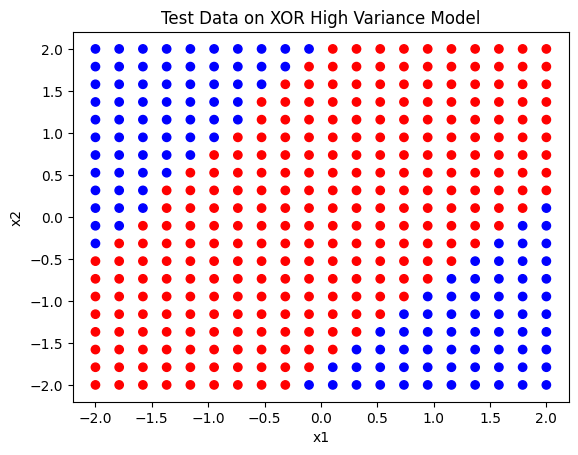

In [ ]:
# Top Performing model with dummy data

test_data = make_test_data(x_range=4) #increase size since we go from -2 -> 2
#small
xor_labels = best_sm['model'].forward(test_data).flatten()
xor_labels = torch.where(xor_labels > 0.5, 1, 0).flatten()
plt.scatter(test_data[:, 0], test_data[:, 1], cmap=cmap, c=xor_labels)
plt.title("Test Data on XOR Low Variance Model")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

#medium
xor_labels = best_md['model'].forward(test_data).flatten()
xor_labels = torch.where(xor_labels > 0.5, 1, 0).flatten()
plt.scatter(test_data[:, 0], test_data[:, 1], cmap=cmap, c=xor_labels)
plt.title("Test Data on XOR Medium Variance Model")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

#large
xor_labels = best_lg['model'].forward(test_data).flatten()
xor_labels = torch.where(xor_labels > 0.5, 1, 0).flatten()
plt.scatter(test_data[:, 0], test_data[:, 1], cmap=cmap, c=xor_labels)
plt.title("Test Data on XOR High Variance Model")
plt.ylabel("x2")
plt.xlabel("x1")
plt.show()

In [ ]:
# Higher dimensions
from itertools import product

def is_xor_true(item):
    neg = 0
    for i in item:
        if i < 0:
            neg += 1
    if neg % 2 != 0:
        return True
    return False

def create_xor(d):
    data = torch.zeros([2**d, d])
    labels = torch.zeros([2**d])
    count = 0
    for i in product([-1, 1], repeat = d):
        data[count] = torch.tensor(i)
        labels[count] = is_xor_true(i)
        count += 1
    return data, labels

xor_4, xor_labels_4 = create_xor(4)
xor_6, xor_labels_6 = create_xor(6)
xor_8, xor_labels_8 = create_xor(8)

In [ ]:
# run the models on the higher dimensional data
hidden_size = 2

epochs = 1000
learning_rate = 0.1

input_size = 4
xor_model = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size)
xor_accuracies_4 = xor_model.fit(xor_4, xor_labels_4, epochs, print_stats=False)

xor_model = MultiLayerPerceptron(learning_rate, input_size, input_size, output_size)
xor_accuracies_4_large = xor_model.fit(xor_4, xor_labels_4, epochs, print_stats=False)

input_size = 6
xor_model = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size)
xor_accuracies_6 = xor_model.fit(xor_6, xor_labels_6, epochs, print_stats=False)

xor_model = MultiLayerPerceptron(learning_rate, input_size, input_size, output_size)
xor_accuracies_6_large = xor_model.fit(xor_6, xor_labels_6, epochs, print_stats=False)

input_size = 8
xor_model = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size)
xor_accuracies_8 = xor_model.fit(xor_8, xor_labels_8, epochs, print_stats=False)

xor_model = MultiLayerPerceptron(learning_rate, input_size, input_size, output_size)
xor_accuracies_8_large = xor_model.fit(xor_8, xor_labels_8, epochs, print_stats=False)

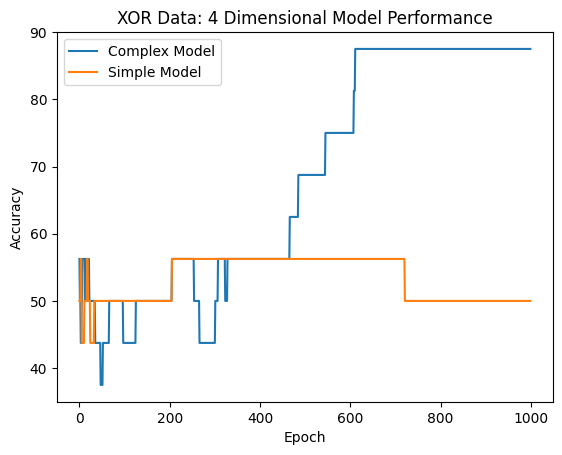

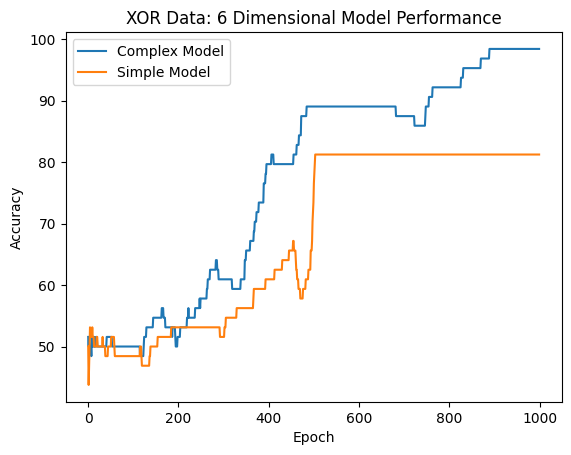

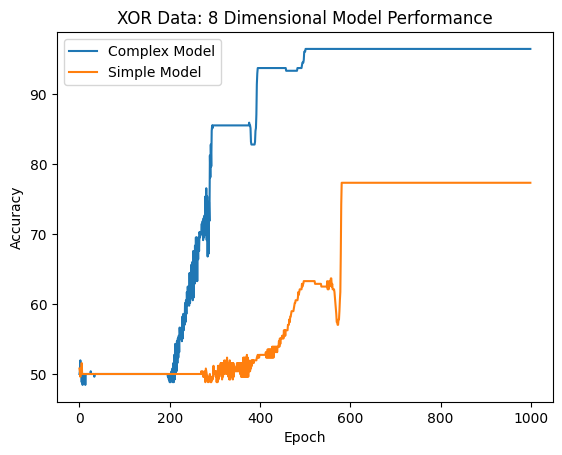

In [ ]:
epochs = [i for i in range(1000)]

plt.plot(epochs, xor_accuracies_4_large)
plt.plot(epochs, xor_accuracies_4)
plt.legend(["Complex Model", "Simple Model"])
plt.title("XOR Data: 4 Dimensional Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.plot(epochs, xor_accuracies_6_large)
plt.plot(epochs, xor_accuracies_6)
plt.legend(["Complex Model", "Simple Model"])
plt.title("XOR Data: 6 Dimensional Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.plot(epochs, xor_accuracies_8_large)
plt.plot(epochs, xor_accuracies_8)
plt.legend(["Complex Model", "Simple Model"])
plt.title("XOR Data: 8 Dimensional Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

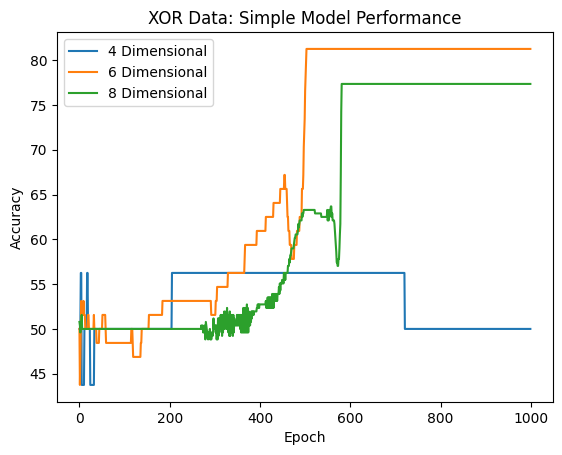

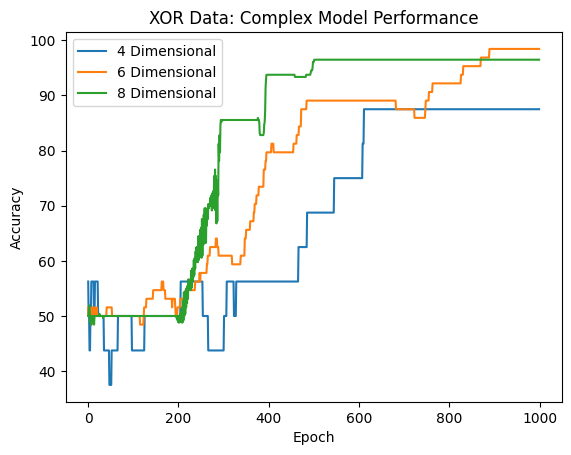

In [ ]:
# Plots by complex/simple model type

#simple models
plt.plot(epochs, xor_accuracies_4)
plt.plot(epochs, xor_accuracies_6)
plt.plot(epochs, xor_accuracies_8)
plt.legend(["4 Dimensional", "6 Dimensional", "8 Dimensional"])
plt.title("XOR Data: Simple Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


#complex models
plt.plot(epochs, xor_accuracies_4_large)
plt.plot(epochs, xor_accuracies_6_large)
plt.plot(epochs, xor_accuracies_8_large)
plt.legend(["4 Dimensional", "6 Dimensional", "8 Dimensional"])
plt.title("XOR Data: Complex Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# Extra Credit
epochs = 500
learning_rate = 0.1
hidden_size = 2
input_size = 2

def get_convergence_i(accuracies):
    for i in range(len(accuracies)):
        if accuracies[i] > 99.99:
            return i
    return -1

converg_i = []
#100 models to check convergence
for i in range(100):
    model = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size)
    accuracies = model.fit(linear_data, linear_labels, epochs, print_stats=False)
    converg_i.append(get_convergence_i(accuracies))
print(f"Average Epoch of Convergence for gaussian model: {numpy.mean(converg_i)}")

# With uniform init
model = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size, random_init=False)
accuracies = model.fit(linear_data, linear_labels, epochs, print_stats=False)
print(f"Epoch of Convergence for uniform model: {get_convergence_i(accuracies)}")

Average Epoch of Convergence for gaussian model: 58.71
Epoch of Convergence for uniform model: 117


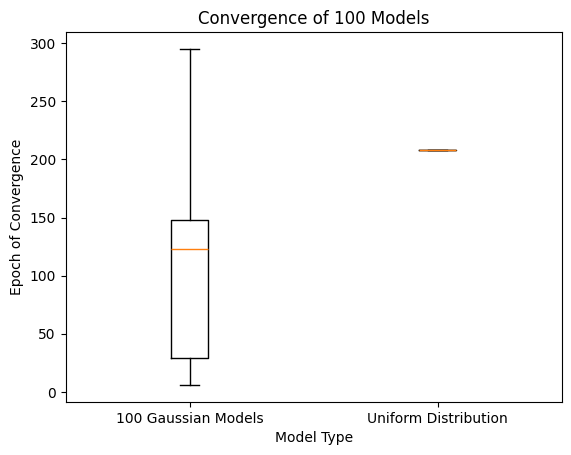

In [ ]:
# plot boxplot
plt.boxplot([converg_i, [208]])
plt.xticks([1, 2], ['100 Gaussian Models', 'Uniform Distribution'])
plt.title("Convergence of 100 Models")
plt.xlabel("Model Type")
plt.ylabel("Epoch of Convergence")
plt.show()

In [ ]:
# Custom Initialization
#custom_weights = [torch.tensor([[0.9, -0.9],[-0.9, 0.9]]), torch.tensor([[-0.9], [0.9]])]
custom_weights = [torch.tensor([[0.9, 0.9],[0.9, 0.9]]), torch.tensor([[0.0], [0.0]])]
model = MultiLayerPerceptron(learning_rate, hidden_size, input_size, output_size, random_init=False, custom_init=custom_weights)
accuracies = model.fit(linear_data, linear_labels, epochs, print_stats=False)
print(f"Epoch of Convergence for custom model: {get_convergence_i(accuracies)}")

Epoch of Convergence for custom model: 171
